In [1]:
import tensorflow as tf
import keras
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)




input_seq_len = bg_pixel_spacetime.shape[1]
input_dim = bg_pixel_spacetime.shape[2]  # Exclude timestamp

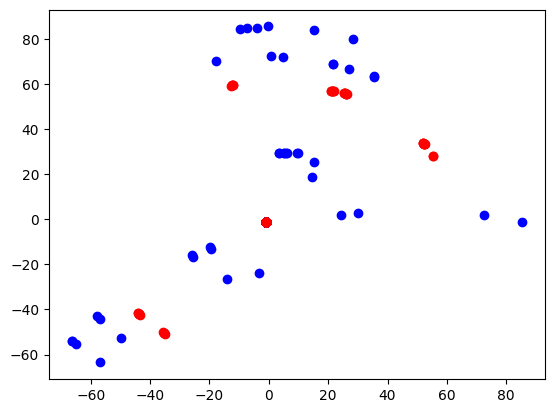

In [3]:
plt.scatter(bg_pixel_spacetime[:1, :, 0], bg_pixel_spacetime[:1, :, 1], color = "blue")
plt.scatter(bg_mppc_spacetime[:1, :, 0], bg_mppc_spacetime[:1, :, 1], color = "red")
plt.show()

In [4]:
pixel_input = keras.Input(shape=(128, 4), name="pixel_input")
mppc_input = keras.Input(shape=(128, 4), name="mppc_input")

In [5]:
from src.model.components import (
    MLP,
)

latent_space = keras.layers.Concatenate(name="concatenate")([pixel_input, mppc_input])
latent_space = keras.layers.Flatten(name="flatten")(latent_space)

latent_space = keras.layers.Dense(
    96, activation="relu", name="dense_latent_space"
)(latent_space)


output = MLP(num_layers=8, output_dim=1, activation="sigmoid", name="output")(
    latent_space
)

model = keras.Model(
    inputs=[pixel_input, mppc_input],
    outputs=output,
    name="ClassificationModel",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

In [6]:
model.summary()

Model: "ClassificationModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pixel_input         │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_input          │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 8)    │          0 │ pixel_input[0][0… │
│ (Concatenate)       │                   │            │ mppc_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1024)      │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_latent_space  │ (None, 96)        │     98,400 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (MLP)        │ (None, 1)         │     15,302 │ dense_latent_spa… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 106,051 (414.26 KB)

 Trainable params: 106,051 (414.26 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from sklearn.model_selection import train_test_split

(
    X_pixel_train,
    X_pixel_test,
    X_mppc_train,
    X_mppc_test,
    y_train,
    y_test,
) = train_test_split(
    np.concatenate([bg_pixel_spacetime[:, :, :], sig_only_pixel_spacetime[:, :, :]], axis=0),
    np.concatenate([bg_mppc_spacetime[:, :, :], sig_only_mppc_spacetime[:, :, :]], axis=0),
    np.concatenate(
        [np.zeros(len(bg_pixel_spacetime)), np.ones(len(sig_only_pixel_spacetime))]
    ),
    test_size=0.2,
    random_state=42,
    shuffle=True,
)


In [8]:
(   
    beam_sig_pixel_train,
    beam_sig_pixel_test,
    beam_sig_mppc_train,
    beam_sig_mppc_test,
    beam_sig_label_train,
    beam_sig_label_test
) = train_test_split(
    np.concatenate([bg_pixel_spacetime[:, :, :], sig_pixel_spacetime[:, :, :]], axis=0),
    np.concatenate([bg_mppc_spacetime[:, :, :], sig_mppc_spacetime[:, :, :]], axis=0),
    np.concatenate(
        [np.zeros(len(bg_pixel_spacetime)), np.ones(len(sig_pixel_spacetime))]
    ),
    test_size=0.2,
    random_state=42,
    shuffle=True,
)


In [9]:
model.fit(
    x=[beam_sig_pixel_train, beam_sig_mppc_train],
    y=beam_sig_label_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    class_weight = {label: np.sum(y_train == label) / len(y_train) for label in np.unique(y_train) if label in [0, 1]}
)

Epoch 1/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - binary_accuracy: 0.4617 - loss: 0.4371 - val_binary_accuracy: 0.4437 - val_loss: 0.6956
Epoch 2/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - binary_accuracy: 0.5578 - loss: 0.3439 - val_binary_accuracy: 0.5600 - val_loss: 0.6934
Epoch 3/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - binary_accuracy: 0.5595 - loss: 0.3427 - val_binary_accuracy: 0.5600 - val_loss: 0.6933
Epoch 4/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - binary_accuracy: 0.5595 - loss: 0.3419 - val_binary_accuracy: 0.5600 - val_loss: 0.6925
Epoch 5/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.5595 - loss: 0.3409 - val_binary_accuracy: 0.5600 - val_loss: 0.6910
Epoch 6/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.5595 - loss: 0.3394 - val_binary_accuracy: 0.5600 - val_loss: 0.6898
Epoch 7/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - binary_accuracy: 0.5595 - loss: 0.3366 - val_binary_accuracy: 0.5600 - val_loss: 0.

In [25]:
test_mppc_length = (beam_sig_mppc_test != -1).all(axis=-1).sum(axis=-1)
test_pixel_length = (beam_sig_pixel_test != -1).all(axis=-1).sum(axis=-1)
train_mppc_length = (beam_sig_mppc_train != -1).all(axis=-1).sum(axis=-1)
train_pixel_length = (beam_sig_pixel_train != -1).all(axis=-1).sum(axis=-1)

In [26]:
mppc_lenght_input = keras.Input(shape=(1,), name="mppc_length_input")
pixel_length_input = keras.Input(shape=(1,), name="pixel_length_input")

input = keras.layers.Concatenate(name="input")(
    [
        mppc_lenght_input,
        pixel_length_input,
    ]
)
encoder = MLP(
    num_layers=3,
    output_dim=10,
    name="encoder",
    activation="relu",
)(input)
decoder = MLP(
    num_layers=3,
    output_dim=1,
    name="decoder",
    activation="sigmoid",
)(encoder)
seq_length_mlp = keras.Model(
    inputs=[mppc_lenght_input, pixel_length_input],
    outputs=decoder,
    name="SeqLengthMLP",
)

In [ ]:
seq_length_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()],
)
seq_length_mlp.summary()

Model: "SeqLengthMLP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mppc_length_input   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_length_input  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input (Concatenate) │ (None, 2)         │          0 │ mppc_length_inpu… │
│                     │                   │            │ pixel_length_inp… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (MLP)       │ (None, 10)        │        178 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (MLP)       │ (None, 1)         │        114 │ encoder[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146 (584.00 B)

 Trainable params: 146 (584.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
seq_length_mlp.fit(
    x=[train_mppc_length, train_pixel_length],
    y=y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    class_weight={label: np.sum(y_train == label) / len(y_train) for label in np.unique(y_train) if label in [0, 1]}
)

Epoch 1/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - binary_accuracy: 0.5331 - loss: 0.3449 - val_binary_accuracy: 0.5337 - val_loss: 0.6933
Epoch 2/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.5336 - loss: 0.3444 - val_binary_accuracy: 0.5339 - val_loss: 0.6939
Epoch 3/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.5336 - loss: 0.3441 - val_binary_accuracy: 0.5335 - val_loss: 0.6934
Epoch 4/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.5336 - loss: 0.3439 - val_binary_accuracy: 0.5334 - val_loss: 0.6921
Epoch 5/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.5336 - loss: 0.3438 - val_binary_accuracy: 0.5335 - val_loss: 0.6923
Epoch 6/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.5336 - loss: 0.3438 - val_binary_accuracy: 0.5336 - val_loss: 0.6923
Epoch 7/100
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.5336 - loss: 0.3437 - val_binary_accuracy: 0.5337 - val_loss: 0.6932

868/868 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


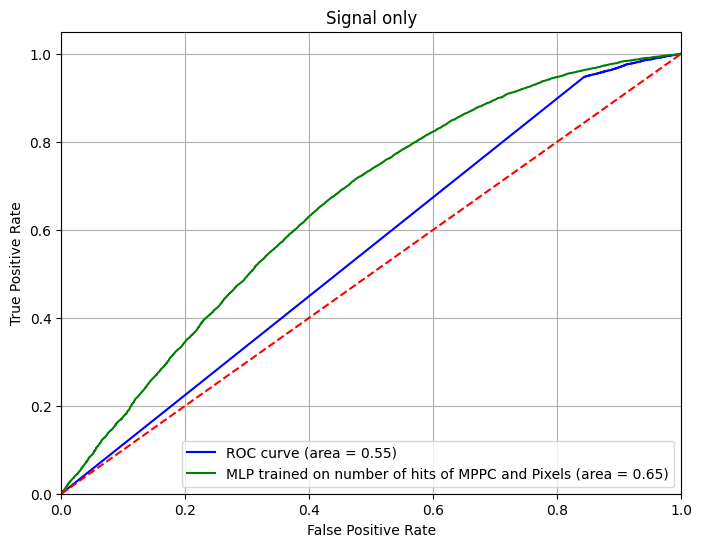

In [ ]:
test_predictions = model.predict([beam_sig_pixel_test, beam_sig_mppc_test])
test_seq_length = seq_length_mlp.predict([test_mppc_length, test_pixel_length])

from sklearn.metrics import confusion_matrix, roc_curve, auc

fpr, tpr, thresholds = roc_curve(beam_sig_label_test, test_predictions)
fpr_seq_length, tpr_seq_length, thresholds_seq_length = roc_curve(beam_sig_label_test, test_seq_length)
roc_auc_seq_length = auc(fpr_seq_length, tpr_seq_length)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label="MLP (area = {:.2f})".format(roc_auc))
plt.plot(
    fpr_seq_length,
    tpr_seq_length,
    color="green",
    label="MLP trained on number of hits of MPPC and Pixels (area = {:.2f})".format(roc_auc_seq_length),
)
plt.title("Signal only")
plt.grid()
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")

868/868 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


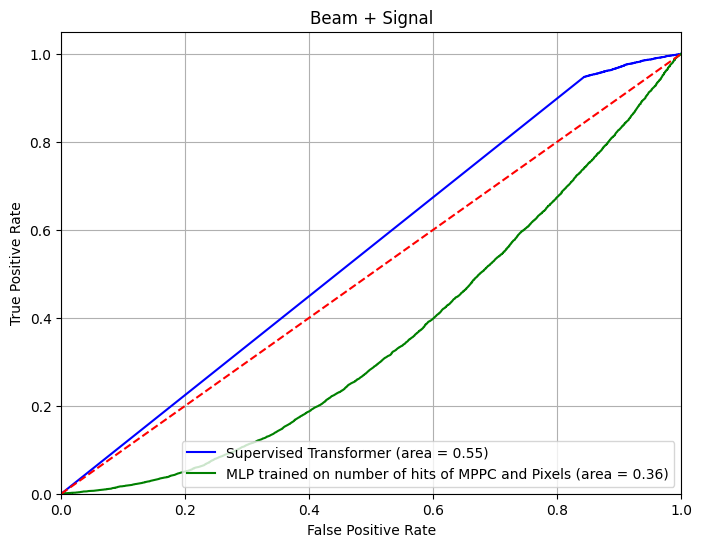

In [ ]:
test_predictions = model.predict([beam_sig_pixel_test, beam_sig_mppc_test])
beam_sig_pixel_length = (beam_sig_pixel_test != -1).all(axis=-1).sum(axis=-1)
beam_sig_mppc_length = (beam_sig_mppc_test != -1).all(axis=-1).sum(axis=-1)


test_seq_length = seq_length_mlp.predict([beam_sig_pixel_length, beam_sig_mppc_length])

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(beam_sig_label_test, test_predictions)
fpr_seq_length, tpr_seq_length, thresholds_seq_length = roc_curve(beam_sig_label_test, test_seq_length)
roc_auc_seq_length = auc(fpr_seq_length, tpr_seq_length)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label="Supervised Transformer (area = {:.2f})".format(roc_auc))
plt.plot(
    fpr_seq_length,
    tpr_seq_length,
    color="green",
    label="MLP trained on number of hits of MPPC and Pixels (area = {:.2f})".format(roc_auc_seq_length),
)
plt.title("Beam + Signal")
plt.grid()
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig("roc_curve_beam_sig.png")